# Profiles and Preferences vs Cups of Coffee Consumed per Day  

**By:** Tiffany Nguyen 

**Group:** 9

**Team Members:** Makafui Amouzouvi, Adam Cook, Nolan Bishop 


## Data Description 

**Number of Rows:** 4042

**Number of Columns:** 57

**Variables:** 44 character, 13 numeric 

**Data Collection:** The data were collected through an online survey completed by participants of the Great American Coffee Taste Test, a public tasting event in October 2023. Participants tasted four coffees and submitted their responses through a structured survey.

**Source:** The dataset comes from the TidyTuesday project which republishes cleaned datasets for educational and exploratory analysis. TidyTuesday requests citing both the original data creator and the TidyTuesday repository. 

Aloe, R. M. (2023). Great American Coffee Taste Test survey data [Data set]. TidyTuesday. Data originally collected by James Hoffmann and Cometeer. https://github.com/rfordatascience/tidytuesday 

## Reviewed Question 

**Question:** How does a person's attributes and preferences relate to the number of cups of coffee they drink per day?

**Question Focus:** This analysis investigates how demographic characteristics and coffee preference behaviors relate to the number of cups of coffee a person consumes per day. The goal is to understand which factors meaningfully explain variation in daily coffee intake among survey respondents. The question focuses on inference, aiming to quantify how expected coffee consumption changes across age groups and preference categories, and prediction, by estimating expected cup counts for different demographic and preference profiles.

**Response Variable:** The response variable is cups of coffee consumed per day (cups). 

**Important Covariates:** Based on the exploratory analysis, the most important covariates are expected age, favourite drink type, caffeine preference, and strength preference. 

**Significance of Other Variables:** Other variables in the dataset, such as roast level, style preferences, or where coffee is consumed, may serve as additional behavioral controls or help account for demographic differences, but they are not included in the primary model to maintain interpretability and avoid excessive sparsity or multicollinearity.

## Exploratory Data Analysis 

**Data Cleaning:** Standaridized values by ensuring that all characters were lowercased. 

**Missing Values:** Excluding submission_id (0% missing) individual variables contain 0.77-99.7% missing values. The variables with the lowest missing value percentages are: age, favorite, where_drink, additions, style, cups, roast_level, expertise, caffeine and strength.

**Class Imbalance:** Looking at the variables with lowest percentages of missing values, key class imbalance insights are listed bellow. 

- "additions" and "where_drink" have especially high class imbalance and could be potentially problematic due to their values containing multiple characteristics that has lead to many different classes as a reult of the many different variations in characteristics and order of the listed characteristics
- "age", "cups", "roast_level", "caffeine" and "strength" have high class imbalance as each has a class that accounts for more than 40% of values.
- "favourite" and "style" have lower class imbalance as no one class has a percentage of more than 30%

**Visualization:** A heatmap was chosen to display the relationship between age, favourite drink type, ans average cups consumed per day. By placing age on the x-axis and favourite drink on the y-axis, it organizes the two categorical variables in a structured grid-like way. The color intensity communicates the average number od cups consumed, allowing patterns and differences across groups to stand out immediately. This helps identify which combinations of age and drink preference are associated with higher or lower consumption. Overall, the visualization directly supports the research goal of predicting cups per dat by revealing meaninful interactions between key predictors.

## _Assignment 1 Code:_

In [50]:
# libraries 
library(tidyverse)
library(ggplot2)

In [7]:
# read in data 
options(readr.show_col_types = FALSE)

coffee_survey <- read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv')

In [8]:
# number of observations and variables 
nrow(coffee_survey)
ncol(coffee_survey)

[1] 4042

[1] 57

In [16]:
# variable names and types 
variable_info <- tibble(
    variable = names(coffee_survey),
    type = sapply(coffee_survey, class))

# group variables by their type (character or numeric) 
wide_variable_info <- variable_info %>%
    group_by(type) %>%
    mutate(idx = row_number()) %>%
    pivot_wider(
        names_from = type,
        values_from = variable) %>%
    select(-idx)

wide_variable_info

character,numeric
<chr>,<chr>
submission_id,expertise
age,coffee_a_bitterness
cups,coffee_a_acidity
where_drink,coffee_a_personal_preference
brew,coffee_b_bitterness
brew_other,coffee_b_acidity
purchase,coffee_b_personal_preference
purchase_other,coffee_c_bitterness
favorite,coffee_c_acidity


In [28]:
# clean data 

# standardize casing 
coffee_clean <- coffee_survey %>%
  mutate(across(where(is.character), ~ tolower(.x)))

write_csv(coffee_clean, "coffee_clean.csv")

In [27]:
# missing values exploration

missing_table <- coffee_clean %>%
    summarise(across(everything(),
        list(n_missing = ~sum(is.na(.)),
             percent_missing = ~mean(is.na(.))))) %>%
    pivot_longer(everything(),
        names_to = c("variable", "stat"),
        names_pattern = "(.*)_(n_missing|percent_missing)") %>%
    pivot_wider(
        names_from = stat,
        values_from = value) %>%
    mutate(percent_missing = round(percent_missing * 100, 2)) %>%
    arrange(n_missing)

missing_table

variable,n_missing,percent_missing
<chr>,<dbl>,<dbl>
submission_id,0,0.00
age,31,0.77
favorite,62,1.53
where_drink,70,1.73
additions,83,2.05
style,84,2.08
cups,93,2.30
roast_level,102,2.52
expertise,104,2.57


In [39]:
# class imbalance exploration function
vars_of_interest <- c(
    "age", "favorite", "where_drink", "additions", 
    "style","cups", "roast_level", "caffeine", "strength")

library(dplyr)

imbalance_table <- function(data, var) {
    data %>%
    count(!!sym(var)) %>%
    mutate(
        pct = round(n / sum(n) * 100, 2)) %>%
    arrange(desc(n)) %>%
    rename(value = !!sym(var))
}

imbalance_tables <- lapply(vars_of_interest, function(v) {
    imbalance_table(coffee_clean, v)
})

names(imbalance_tables) <- vars_of_interest

In [40]:
# class imbalance for "age" 
imbalance_tables$age

value,n,pct
<chr>,<int>,<dbl>
25-34 years old,1986,49.13
35-44 years old,960,23.75
18-24 years old,461,11.41
45-54 years old,302,7.47
55-64 years old,187,4.63
>65 years old,95,2.35
NA,31,0.77
<18 years old,20,0.49


In [41]:
# class imbalance for "favorite" 
imbalance_tables$favorite

value,n,pct
<chr>,<int>,<dbl>
pourover,1084,26.82
latte,680,16.82
regular drip coffee,442,10.94
cappuccino,341,8.44
espresso,330,8.16
cortado,312,7.72
americano,249,6.16
iced coffee,156,3.86
mocha,118,2.92


In [42]:
# class imbalance for "where_drink"
imbalance_tables$where_drink

value,n,pct
<chr>,<int>,<dbl>
at home,1625,40.20
"at home, at a cafe",416,10.29
"at home, at the office",407,10.07
"at the office, at home",229,5.67
at the office,141,3.49
"at home, on the go",121,2.99
"at a cafe, at home",85,2.10
"at home, at the office, at a cafe",79,1.95
at a cafe,71,1.76


In [43]:
# class imbalance for "additions"
imbalance_tables$additions

value,n,pct
<chr>,<int>,<dbl>
no - just black,2154,53.29
"milk, dairy alternative, or coffee creamer",772,19.10
"no - just black, milk, dairy alternative, or coffee creamer",273,6.75
"milk, dairy alternative, or coffee creamer, sugar or sweetener",272,6.73
NA,83,2.05
"milk, dairy alternative, or coffee creamer, flavor syrup",76,1.88
"milk, dairy alternative, or coffee creamer, no - just black",69,1.71
"milk, dairy alternative, or coffee creamer, sugar or sweetener, flavor syrup",57,1.41
sugar or sweetener,50,1.24


In [44]:
# class imbalance for "style" 
imbalance_tables$style

value,n,pct
<chr>,<int>,<dbl>
fruity,953,23.58
chocolatey,628,15.54
full bodied,474,11.73
bright,349,8.63
nutty,304,7.52
sweet,294,7.27
caramalized,280,6.93
juicy,274,6.78
bold,203,5.02


In [48]:
imbalance_tables$cups 

value,n,pct
<chr>,<int>,<dbl>
2,1663,41.14
1,1277,31.59
3,473,11.70
less than 1,348,8.61
4,121,2.99
NA,93,2.30
more than 4,67,1.66


In [45]:
# class imbalance for "roast_level"
imbalance_tables$roast_level

value,n,pct
<chr>,<int>,<dbl>
light,1778,43.99
medium,1557,38.52
dark,409,10.12
NA,102,2.52
nordic,78,1.93
blonde,74,1.83
italian,23,0.57
french,21,0.52


In [46]:
# class imbalance for "caffeine" 
imbalance_tables$caffeine

value,n,pct
<chr>,<int>,<dbl>
full caffeine,3576,88.47
half caff,205,5.07
decaf,136,3.36
NA,125,3.09


In [47]:
# class imbalance for "strength" 
imbalance_tables$strength

value,n,pct
<chr>,<int>,<dbl>
somewhat strong,1791,44.31
medium,1432,35.43
very strong,433,10.71
somewhat light,217,5.37
NA,126,3.12
weak,43,1.06


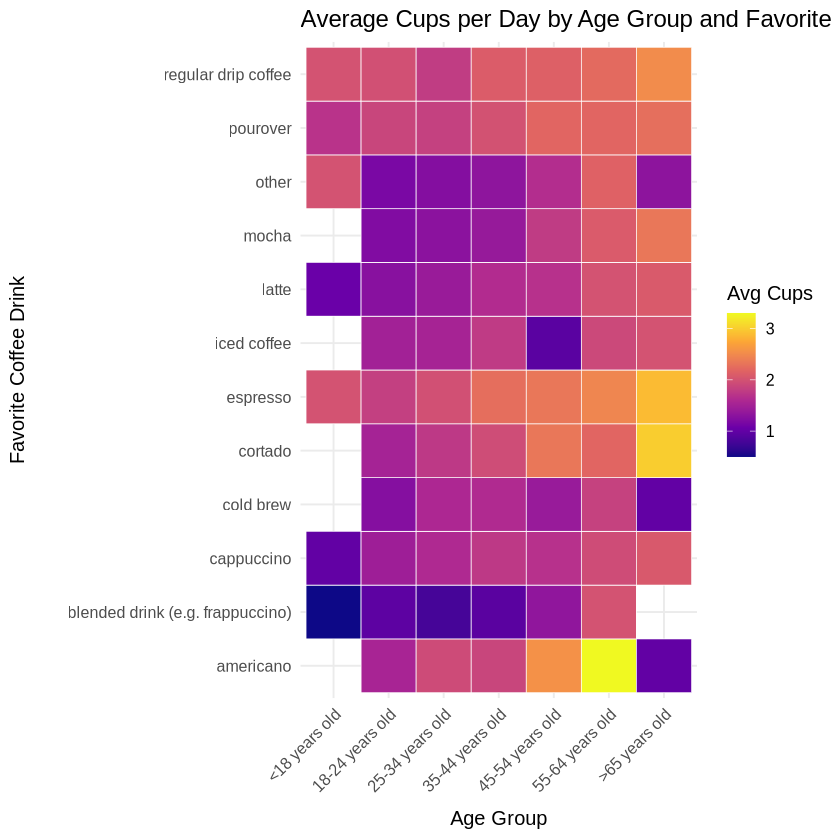

In [57]:
# visualization 

coffee_clean %>%
    filter(!is.na(age), !is.na(cups), !is.na(favorite)) %>%
    mutate(
    age = factor(age, levels = c(
      "<18 years old",
      "18-24 years old",
      "25-34 years old",
      "35-44 years old",
      "45-54 years old",
      "55-64 years old",
      ">65 years old"
    )),
    cups_num = case_when(
        cups == "less than 1" ~ 0.5,
        cups == "1" ~ 1,
        cups == "2" ~ 2,
        cups == "3" ~ 3,
        cups == "4" ~ 4,
        cups == "more than 4" ~ 5)) %>%
    group_by(age, favorite) %>%
    summarise(avg_cups = mean(cups_num), n = n(), .groups = "drop") %>%
    ggplot(aes(x = age, y = favorite, fill = avg_cups)) +
    geom_tile(color = "white") +
    scale_fill_viridis_c(option = "C", name = "Avg Cups") +
    labs(
        title = "Average Cups per Day by Age Group and Favorite Drink",
        x = "Age Group",
        y = "Favorite Coffee Drink") +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Methods and Plan 

**Reviewed Question:** How does a person's attributes and preferences relate to the number of cups of coffee they drink per day?

**Method:** A Poisson regression model with a log link will be used to model the expected number of cups consumed per day as a function of demographic and preference‑based predictors. This method is appropriate because the response variable represents a non‑negative count‑like quantity, and Poisson regression provides a way to estimate multiplicative effects (rate ratios) of categorical predictors on expected counts. The model will include age group, favorite drink type, caffeine preference, and strength preference, as these variables showed clear structure, low missingness, and meaningful variation in the exploratory analysis.

**Assumptions and Limitations:** The Poisson model assumes that the response variable is a count and that the conditional mean equals the conditional variance. In this dataset, the cups variable is categorical and binned rather than an exact count, so treating it as a numeric count introduces approximation error. The model also assumes independence of observations, which may be imperfect if respondents share environments or habits not captured in the data. Overdispersion is a potential limitation, as real world consumption data often exhibit greater variability than the Poisson model allows. If present, it may lead to underestimated standard errors. Finally, because the data are observational, the model identifies associations rather than causal effects, and unmeasured confounding may influence the observed relationships.


## Computational Code and Output

**Visualization:** The coefficient plot displays the estimated rate ratios from the Poisson regression, showing how each predictor is associated with the expected number of cups consumed per day. It was chosen because it provides a clean, interpretable summary of the model’s results, highlighting which age groups and coffee preference categories increase or decrease expected consumption relative to their reference levels. The horizontal confidence intervals make it easy to see which effects are statistically meaningful by indicating whether they cross the “no‑effect” line at 1. This visualization supports the research question by clearly identifying which demographic and preference factors are most strongly associated with higher or lower coffee intake, helping explain variation in daily consumption patterns.

**Interpretation:** The Poisson regression results show that older age groups, particularly individuals aged 55–64 and over 65, have significantly higher expected coffee consumption compared to the <18 reference group, with rate ratios of approximately 1.59 and 1.70. Several favorite drink categories including latte, mocha, iced coffee, cold brew, and blended drinks are associated with substantially lower expected cup counts, while espresso and pourover do not differ meaningfully from the reference drink. Caffeine preference exhibits the strongest effect. Full‑caffeine drinkers consume about twice as many cups per day, and half‑caffeine drinkers also show significantly higher intake. Strength preference also plays a role, with somewhat strong and very strong drinkers consuming more, while weak and somewhat light preferences correspond to lower expected consumption.

## _Assignment 2 Code:_

In [61]:
# analysis 

# fit poisson regression using selected predictors

coffee_model <- coffee_clean %>%
  filter(
    !is.na(cups),
    !is.na(age),
    !is.na(favorite),
    !is.na(caffeine),
    !is.na(strength)
  ) %>%
  mutate(
    cups_num = case_when(
      cups == "less than 1" ~ 0,
      cups == "1" ~ 1,
      cups == "2" ~ 2,
      cups == "3" ~ 3,
      cups == "4" ~ 4,
      cups == "more than 4" ~ 5
    ),
    age = factor(age, levels = c(
      "<18 years old", "18-24 years old", "25-34 years old",
      "35-44 years old", "45-54 years old", "55-64 years old",
      ">65 years old"
    ))
  )

poisson_fit <- glm(
  cups_num ~ age + favorite + caffeine + strength,
  data = coffee_model,
  family = poisson(link = "log")
)

# compact coefficient table with exponentiated estimates (rate ratios)
coef_table <- data.frame(
  term = names(coef(poisson_fit)),
  rate_ratio = exp(coef(poisson_fit)),
  p_value = summary(poisson_fit)$coefficients[,4]
)

coef_table


,term,rate_ratio,p_value
,<chr>,<dbl>,<dbl>
(Intercept),(Intercept),0.7218309,1.934700e-01
age18-24 years old,age18-24 years old,1.1199510,6.186957e-01
age25-34 years old,age25-34 years old,1.2058211,4.051610e-01
age35-44 years old,age35-44 years old,1.3482890,1.849760e-01
age45-54 years old,age45-54 years old,1.4652676,9.372473e-02
age55-64 years old,age55-64 years old,1.5925047,4.285522e-02
age>65 years old,age>65 years old,1.7032479,2.353567e-02
favoriteblended drink (e.g. frappuccino),favoriteblended drink (e.g. frappuccino),0.4051749,3.792625e-06
favoritecappuccino,favoritecappuccino,0.8213678,1.770258e-03


`height` was translated to `width`.


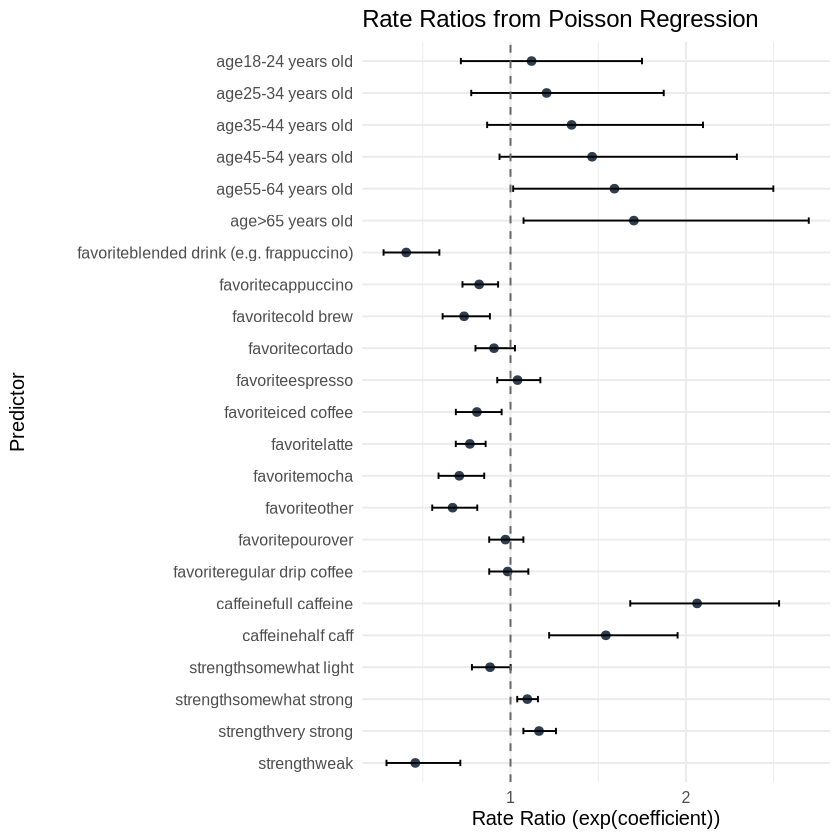

In [62]:
# visualization 

coef_df <- data.frame(
  term = names(coef(poisson_fit)),
  estimate = coef(poisson_fit),
  p_value = summary(poisson_fit)$coefficients[,4]
) %>%
  mutate(
    rate_ratio = exp(estimate),
    lower_ci = exp(estimate - 1.96 * summary(poisson_fit)$coefficients[,2]),
    upper_ci = exp(estimate + 1.96 * summary(poisson_fit)$coefficients[,2])
  ) %>%
  filter(term != "(Intercept)") %>%   # remove intercept for clarity
  mutate(
    term = factor(term, levels = rev(term))  # reverse for plotting
  )

# plot rate ratios with 95% CI
ggplot(coef_df, aes(x = rate_ratio, y = term)) +
  geom_point(color = "#2C3E50", size = 2) +
  geom_errorbarh(aes(xmin = lower_ci, xmax = upper_ci), height = 0.2) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40") +
  scale_x_continuous("Rate Ratio (exp(coefficient))") +
  labs(
    title = "Rate Ratios from Poisson Regression",
    y = "Predictor",
    x = "Rate Ratio (95% CI)"
  ) +
  theme_minimal(base_size = 12)


## AI Tool Disclosure: 

AI tools were not used. 